In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime
from datetime import datetime
import matplotlib.patches as mpatches
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [3]:
tissues = ["kidney", "liver",  "lung", "heart", 
           "brainFC", "brainHip", "brainCB",
           "BAT", "testis",
            "muscle", "colon", "spleen"] 

len(tissues)

12

In [4]:
histone_mark = "H3K9me3"
df_dge_list = []
for tissue in tissues:
    path = f"~/projects/paired_seq_tag/results/{tissue}-merged/dna-qc/{histone_mark}_bin_edgeR_27M_over_3M.csv"
    df_tmp = pd.read_csv(path)
    df_tmp["tissue"] = tissue  # 添加 tissue 信息列
    df_tmp["histone_mark"] = histone_mark  # 添加组蛋白修饰类型
    df_tmp["tissue_ct"] = tissue + '-' + df_tmp["cell_type"]
    df_dge_list.append(df_tmp[['histone_mark', 'gene', 'logFC', 'logCPM', 'LR', 'PValue', 'FDR','cell_type', 'p_val', 'p_val_adj', 'avg_logFC', 'tissue', 'tissue_ct']])
df_dge = pd.concat(df_dge_list, ignore_index=True)
df_dge.shape

(15157441, 13)

In [5]:
logfc_cutoff = np.log2(1.1)

df_dge_count = (
    df_dge
    .assign(
        up_pval = (df_dge["PValue"] < 0.05) & (df_dge["avg_logFC"] > logfc_cutoff),
        down_pval = (df_dge["PValue"] < 0.05) & (df_dge["avg_logFC"] < -logfc_cutoff),
        up_fdr = (df_dge["FDR"] < 0.05) & (df_dge["avg_logFC"] > logfc_cutoff),
        down_fdr = (df_dge["FDR"] < 0.05) & (df_dge["avg_logFC"] < -logfc_cutoff),
    )
    .groupby(["tissue_ct", "histone_mark"])
    .agg(
        total=("PValue", "size"),
        up_pval=("up_pval", "sum"),
        down_pval=("down_pval", "sum"),
        up_fdr=("up_fdr", "sum"),
        down_fdr=("down_fdr", "sum"),
    )
    .reset_index()
)
df_dge_count["total_pval"] = df_dge_count["up_pval"] + df_dge_count["down_pval"]
df_dge_count.shape

(191, 8)

In [6]:
df_dge_count.head()

,tissue_ct,histone_mark,total,up_pval,down_pval,up_fdr,down_fdr,total_pval
0,BAT-ASPC,H3K9me3,15570,840,1310,116,308,2150
1,BAT-Adipocyte,H3K9me3,64192,3843,3954,346,311,7797
2,BAT-B_cell,H3K9me3,141684,4506,4258,0,0,8764
3,BAT-Brown_adipocyte,H3K9me3,212917,15948,20881,3570,7308,36829
4,BAT-MSC,H3K9me3,41804,2126,1096,0,0,3222


In [7]:
df_dge_count[df_dge_count.tissue_ct.str.contains("Fibroblast")]

,tissue_ct,histone_mark,total,up_pval,down_pval,up_fdr,down_fdr,total_pval
16,brainCB-Fibroblasts_Other,H3K9me3,60996,3129,1331,0,0,4460
34,brainFC-Fibroblasts_Other,H3K9me3,66189,1356,3441,0,0,4797
65,brainHip-Fibroblasts_Other,H3K9me3,31197,264,4908,0,0,5172
88,colon-Fibroblast,H3K9me3,123805,6603,1136,0,0,7739
105,heart-Fibroblast,H3K9me3,116968,6430,5629,313,324,12059
116,kidney-Fibroblast,H3K9me3,219695,17460,5299,6,5,22759
171,spleen-Fibroblast,H3K9me3,7076,605,19,0,0,624


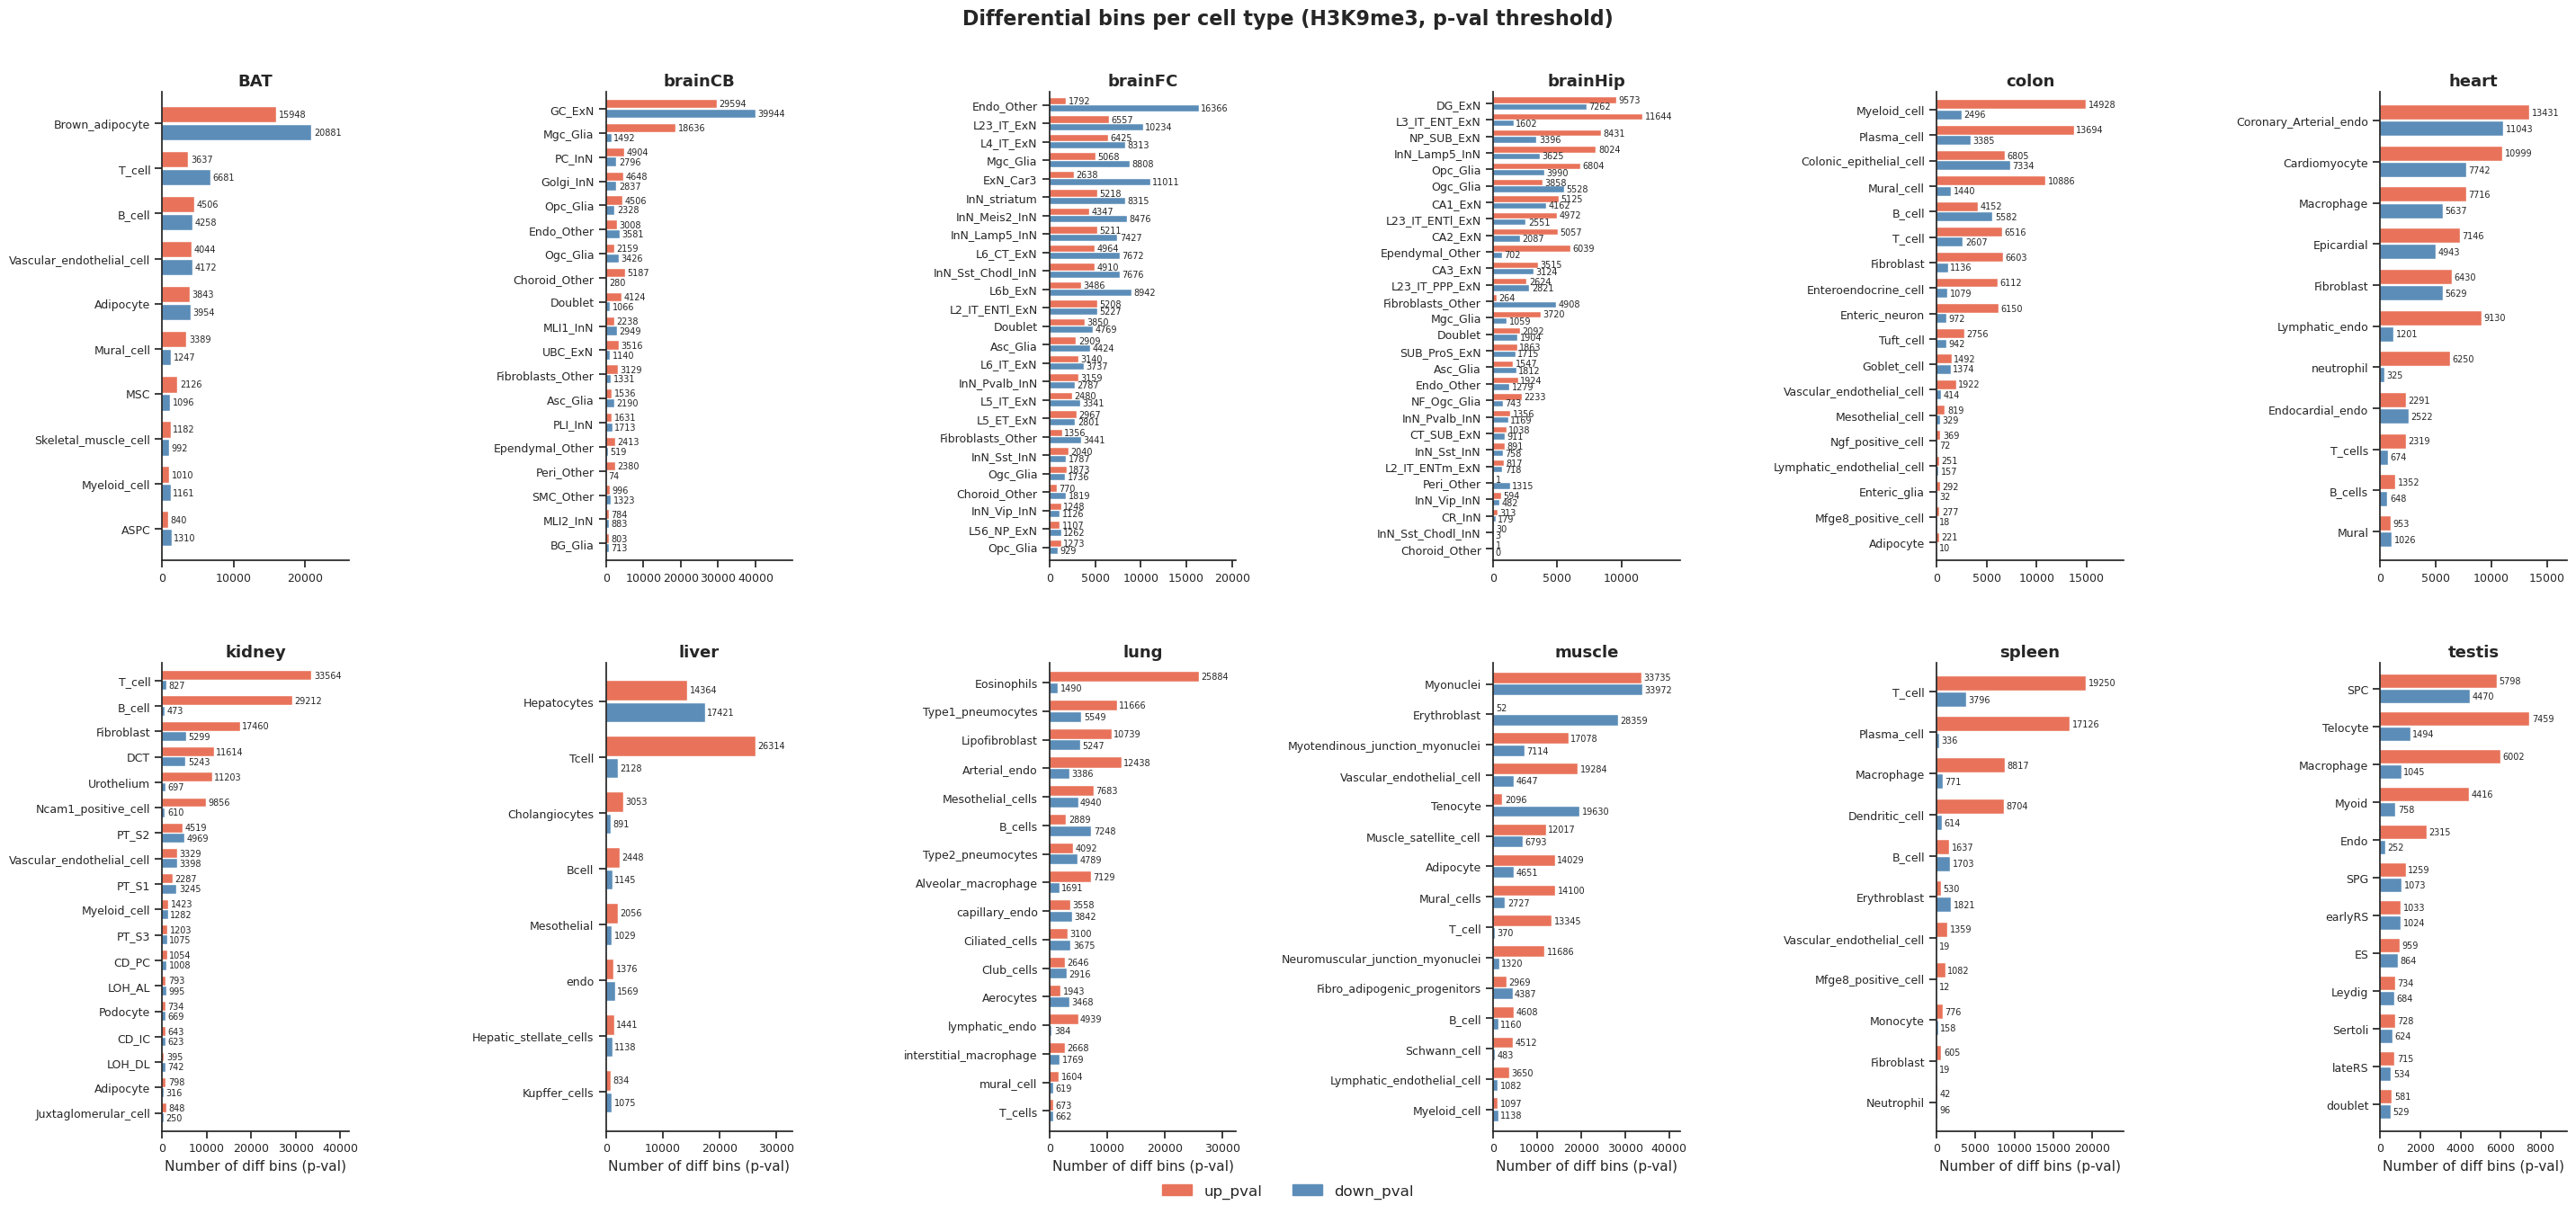

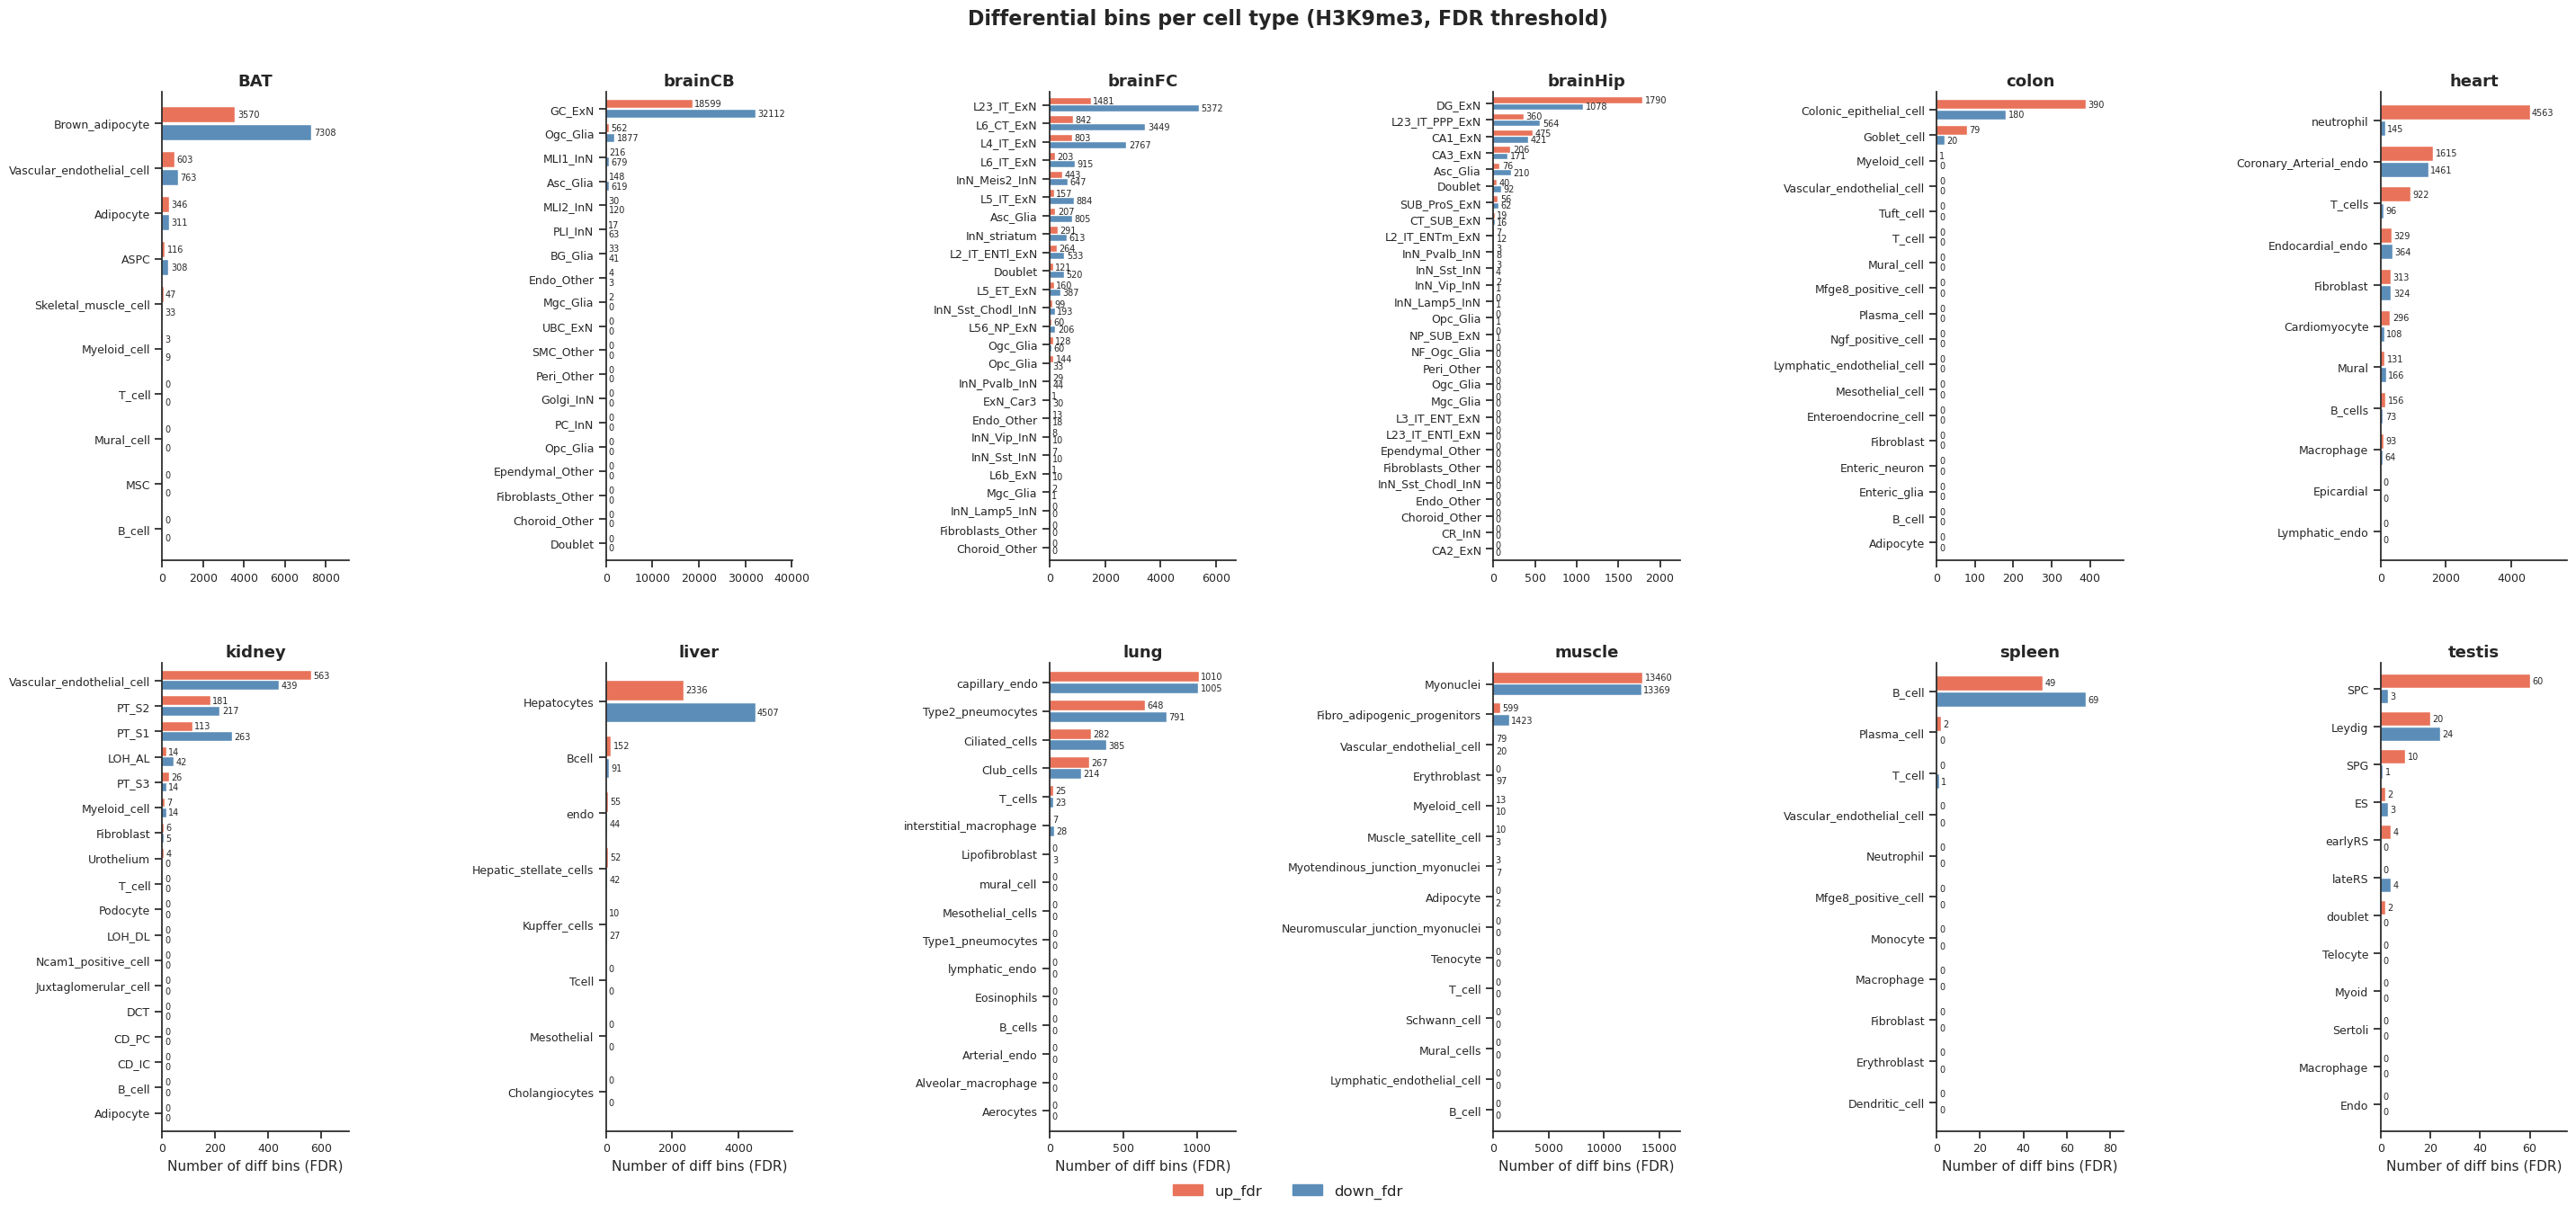

In [9]:
UP_COLOR   = "#E8735A"   # warm red  — up
DOWN_COLOR = "#5B8DB8"   # steel blue — down

sns.set_theme(style="ticks", font_scale=1.0)

# ── Load data ─────────────────────────────────────────────────────────────────
df = df_dge_count
df["tissue"]    = df["tissue_ct"].str.split("-").str[0]
df["cell_type"] = df["tissue_ct"].str.split("-", n=1).str[1]

tissue_order = sorted(df["tissue"].unique())

# ── Core plot function ────────────────────────────────────────────────────────
def plot_diff_bins(up_col, down_col, sort_col, xlabel, title, filename):
    """
    2×6 horizontal grouped bar plot.
    Each tissue = one panel; each cell type = two offset bars (up / down).

    Parameters
    ----------
    up_col   : column name for up counts   (e.g. 'up_pval' or 'up_fdr')
    down_col : column name for down counts (e.g. 'down_pval' or 'down_fdr')
    sort_col : column used to sort cell types within each panel
    xlabel   : x-axis label
    title    : figure suptitle
    filename : output filename (without extension)
    """
    bar_h, gap = 0.35, 0.05
    n_cols, n_rows = 6, 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 6.5 * n_rows))

    for idx, tissue in enumerate(tissue_order):
        ax = axes.flat[idx]
        sub = df[df["tissue"] == tissue].copy().sort_values(sort_col, ascending=True)
        n_ct = len(sub)

        y    = np.arange(n_ct)
        y_up = y + gap / 2 + bar_h / 2   # up bar: above centre
        y_dn = y - gap / 2 - bar_h / 2   # down bar: below centre

        ax.barh(y_up, sub[up_col],   height=bar_h, color=UP_COLOR,   edgecolor="white", linewidth=0.3)
        ax.barh(y_dn, sub[down_col], height=bar_h, color=DOWN_COLOR, edgecolor="white", linewidth=0.3)

        # Value labels on every bar
        max_val = max(sub[[up_col, down_col]].max().max(), 1)
        for i, (u, d) in enumerate(zip(sub[up_col], sub[down_col])):
            ax.text(u + max_val * 0.015, y_up[i], str(int(u)), va="center", ha="left", fontsize=7)
            ax.text(d + max_val * 0.015, y_dn[i], str(int(d)), va="center", ha="left", fontsize=7)

        ax.set_yticks(y)
        ax.set_yticklabels(sub["cell_type"].tolist(), fontsize=9)
        ax.set_ylim(-0.7, n_ct - 0.3)
        ax.set_title(tissue, fontsize=13, fontweight="bold", pad=5)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="x", labelsize=9)
        ax.set_xlim(0, max_val * 1.25)

    for col in range(n_cols):
        axes[1, col].set_xlabel(xlabel, fontsize=11)
    for idx in range(len(tissue_order), n_cols * n_rows):
        axes.flat[idx].set_visible(False)

    legend_handles = [
        mpatches.Patch(color=UP_COLOR,   label=up_col),
        mpatches.Patch(color=DOWN_COLOR, label=down_col),
    ]
    fig.legend(handles=legend_handles,
               loc="lower center", bbox_to_anchor=(0.5, -0.02),
               ncol=2, fontsize=12, frameon=False)

    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout(h_pad=4, w_pad=3)


# ── Generate plots ────────────────────────────────────────────────────────────

# p-value threshold
plot_diff_bins(
    up_col   = "up_pval",
    down_col = "down_pval",
    sort_col = "total_pval",
    xlabel   = "Number of diff bins (p-val)",
    title    = "Differential bins per cell type (H3K9me3, p-val threshold)",
    filename = "diff_bins_pval_per_tissue",
)

# FDR threshold
df["total_fdr"] = df["up_fdr"] + df["down_fdr"]
plot_diff_bins(
    up_col   = "up_fdr",
    down_col = "down_fdr",
    sort_col = "total_fdr",
    xlabel   = "Number of diff bins (FDR)",
    title    = "Differential bins per cell type (H3K9me3, FDR threshold)",
    filename = "diff_bins_fdr_per_tissue",
)
